In [1]:
import hoda
import tensorly as tl

tl.set_backend('cupy', local_threadsafe=False)
print(tl.get_backend())
%pip install toeplitzlda
%pip freeze | grep moabb

cupy

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
moabb==1.0.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation

paradigm = P300(resample=48)
datasets = [
    #BI2012(),
    #BI2013a(),
    #BI2014a(),
    #BI2014b(),
    #BI2015a(),
    #BI2015b(),
    BNCI2014_008(),
    #BNCI2014_009(),
    #EPFLP300(),
    #BNCI2015_003(),
    #Cattan2019_VR(),
    #Huebner2017(),
    #Huebner2018(),
    #Lee2019_ERP(),
    #Sosulski2019(),
]

evaluation = WithinSessionEvaluation(
    paradigm=paradigm,
    datasets=datasets,
    overwrite=False,
    random_state=42,
    n_jobs=4,
    suffix='sfreq-48',
)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


In [3]:
from sklearn.pipeline import Pipeline
from hoda.hoda import HODA, BTTDA, InfoBTTDA, GreedyBTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from hoda.classification import ToeplitzLDAWrapper, SelectF
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from mne.decoding import Scaler
from sklearn.linear_model import LogisticRegression
from hoda.tensorize import  Vectorize, Tensorize

pipelines = dict()


hoda_params = dict(
    max_iter=128,
    tol=1e-8,
    init ='eye',
    random_state=42,
    shrinkage='lw',
    solver='lanczos',
    taper=False,
    forward=False,
    obj='rt',
    toeplitz=None,
    delta=None,
)


pipelines['HODA'] = Pipeline([
    ('tensor', Tensorize()),
    ('clf', GridSearchCV(
        Pipeline([
            ('hoda', HODA(**hoda_params)),
            ('vec', Vectorize()),
            ('zscore', StandardScaler()),
            ('lda', LDA(shrinkage='auto', solver='lsqr')),
        ]),
        param_grid=dict(hoda__rank=[1,2,4,8]),
        n_jobs=4
    )),
])

pipelines['BTTDA_8'] = Pipeline([
    ('bttda', GreedyBTTDA(
        ranks=[None]*8,
        truncate=True,
        hoda_params=dict(
            **hoda_params,
        ),
        extra_train_info=False,
        verbose=False
    )),
    ('vec', Vectorize()),
    ('zscore', StandardScaler()),
    ('lda', LDA(shrinkage='auto', solver='lsqr'))
])

pipelines['tLDA'] = ToeplitzLDAWrapper()


In [4]:
#import warnings
#warnings.filterwarnings("ignore")

results = evaluation.process(pipelines)

BNCI2014-008-WithinSession:   0%|                                                                                                       | 0/8 [00:00<?, ?it/s]

No hdf5_path provided, models will not be saved.


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pic

No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession:  25%|███████████████████████▌                                                                      | 2/8 [09:27<28:22, 283.72s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


...

BNCI2014-008-WithinSession:  75%|██████████████████████████████████████████████████████████████████████▌                       | 6/8 [26:57<08:37, 258.75s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession:  88%|██████████████████████████████████████████████████████████████████████████████████▎           | 7/8 [31:14<04:18, 258.01s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [35:03<00:00, 262.94s/it]


In [5]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.835286,5.675900,4200.0,1,0,8,1,BNCI2014-008,HODA
1,0.749716,4.744700,4200.0,2,0,8,1,BNCI2014-008,HODA
2,0.883163,4.188107,4200.0,3,0,8,1,BNCI2014-008,HODA
3,0.811943,4.585832,4200.0,4,0,8,1,BNCI2014-008,HODA
4,0.833371,5.135735,4200.0,5,0,8,1,BNCI2014-008,HODA
5,0.873102,5.815528,4200.0,6,0,8,1,BNCI2014-008,HODA
6,0.862776,5.674463,4200.0,7,0,8,1,BNCI2014-008,HODA
7,0.946271,3.772630,4200.0,8,0,8,1,BNCI2014-008,HODA
8,0.830173,0.077131,4200.0,1,0,8,1,BNCI2014-008,tLDA
9,0.803110,0.075239,4200.0,2,0,8,1,BNCI2014-008,tLDA


In [6]:
results.groupby(['dataset','session', 'pipeline']).aggregate('mean') 

/tmp/ipykernel_42394/3374554284.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  results.groupby(['dataset','session', 'pipeline']).aggregate('mean')


score       time  samples  channels  \
dataset      session pipeline                                           
BNCI2014-008 0       BTTDA_8   0.861921  51.751179   4200.0       8.0   
                     HODA      0.849454   4.949112   4200.0       8.0   
                     tLDA      0.861197   0.078993   4200.0       8.0   

                               n_sessions  
dataset      session pipeline              
BNCI2014-008 0       BTTDA_8          1.0  
                     HODA             1.0  
                     tLDA             1.0

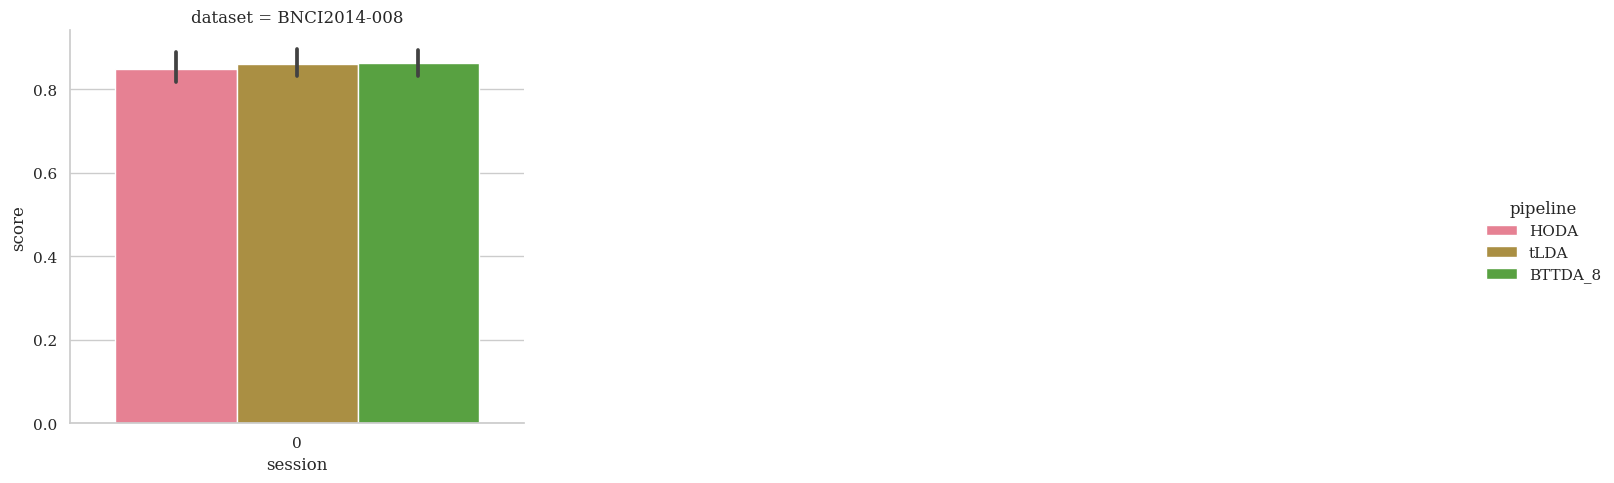

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

order = results.groupby('pipeline')
order = order.score.aggregate('mean')
order = order.sort_values()


sns.catplot(data=results , x='session', y='score', col='dataset',hue='pipeline', col_wrap=3,kind='bar')
plt.show()

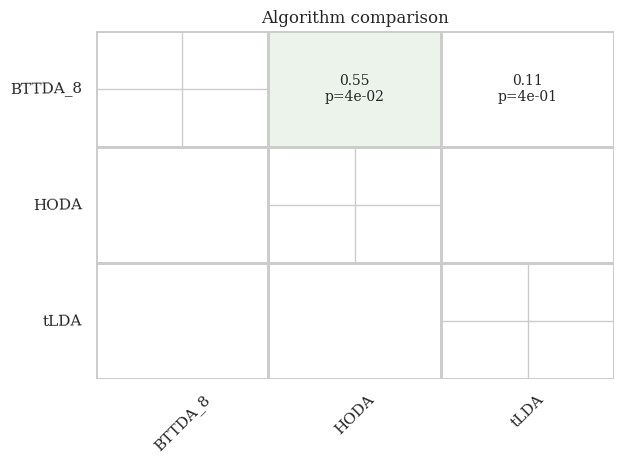

In [8]:
from moabb.analysis.meta_analysis import compute_dataset_statistics, find_significant_differences
from moabb.analysis.plotting import summary_plot
import matplotlib.pyplot as plt

stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)
plt.show()

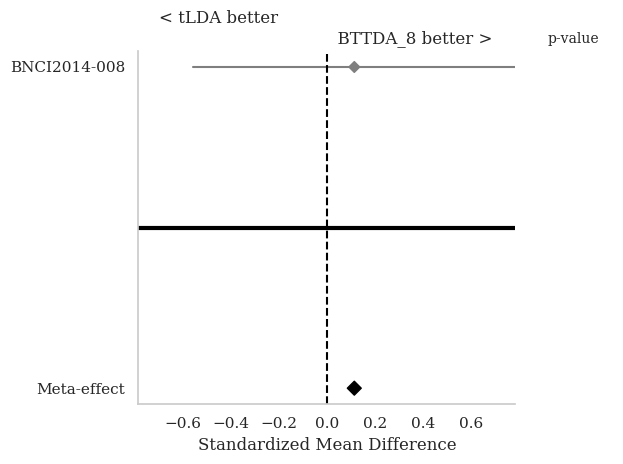

/usr/local/lib/python3.10/dist-packages/pandas/plotting/_matplotlib/core.py:1259: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(


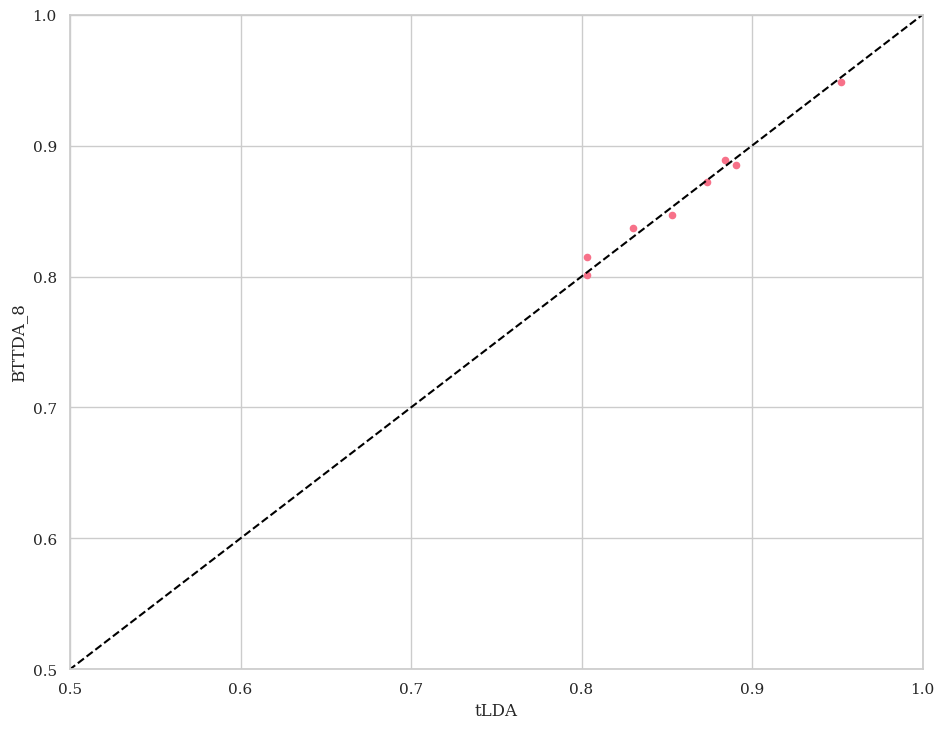

In [12]:
from moabb.analysis.plotting import meta_analysis_plot, paired_plot
_ = meta_analysis_plot(stats,'BTTDA_8',  'tLDA')
plt.show()
_  = paired_plot(results,  'tLDA','BTTDA_8')
plt.show()
